# 01 — Hyperparameter Tuning: Random Forest (Optuna)
### Heads-Up | Stage 8: Hyperparameter Optimization (part 1 of 6)

Random Forest is our current Recall leader (0.6172 at default settings). This notebook tunes it properly with Optuna, optimizing directly for Recall on the validation set, one trial = one fit + one validation score, per the compute-cost decision already logged (full cross-validation inside every trial would be too slow across our full candidate set).


## Setup

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import joblib

train_df = pd.read_csv(Path('../../../data/processed/model_ready_train.csv'))
val_df = pd.read_csv(Path('../../../data/processed/model_ready_val.csv'))

bool_cols = train_df.select_dtypes(include='bool').columns
train_df[bool_cols] = train_df[bool_cols].astype(int)
val_df[bool_cols] = val_df[bool_cols].astype(int)

X_train = train_df.drop(columns=['Late_delivery_risk'])
y_train = train_df['Late_delivery_risk']
X_val = val_df.drop(columns=['Late_delivery_risk'])
y_val = val_df['Late_delivery_risk']

print(f"X_train: {X_train.shape}, X_val: {X_val.shape}")


X_train: (46026, 28), X_val: (7890, 28)


## 1. Define the Optuna search space and objective

In [2]:
import optuna
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import recall_score

optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial):
  
    max_depth_choice = trial.suggest_categorical('max_depth_is_none', [True, False])
    if max_depth_choice:
        max_depth = None
    else:
        max_depth = trial.suggest_int('max_depth', 5, 50)

    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'max_depth': max_depth,
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
        'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2', None]),
        'class_weight': trial.suggest_categorical('class_weight', [None, 'balanced']),
        'random_state': 42,
        'n_jobs': -1,
    }
    model = RandomForestClassifier(**params)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_val)
    return recall_score(y_val, y_pred)


## 2. Run the study

In [5]:
import time

N_TRIALS = 50
start = time.time()

def progress_callback(study, trial):
    done = len(study.trials)
    elapsed = time.time() - start
    avg = elapsed / done
    remaining = avg * (N_TRIALS - done)
    print(
        f"Trial {done}/{N_TRIALS} | this trial: {trial.duration.total_seconds():.0f}s | "
        f"elapsed: {elapsed/60:.1f} min | ETA: {remaining/60:.1f} min | "
        f"best so far: {study.best_value:.4f}"
    )

study = optuna.create_study(direction='maximize', study_name='rf_recall_tuning')
study.optimize(objective, n_trials=N_TRIALS, callbacks=[progress_callback])

print(f"Best validation Recall: {study.best_value:.4f}")
print(f"Best params: {study.best_params}")

Trial 1/50 | this trial: 39s | elapsed: 0.7 min | ETA: 32.3 min | best so far: 0.5908
Trial 2/50 | this trial: 188s | elapsed: 3.8 min | ETA: 91.1 min | best so far: 0.6095
Trial 3/50 | this trial: 13s | elapsed: 4.0 min | ETA: 62.8 min | best so far: 0.6095
Trial 4/50 | this trial: 96s | elapsed: 5.6 min | ETA: 64.5 min | best so far: 0.6095
Trial 5/50 | this trial: 7s | elapsed: 5.7 min | ETA: 51.6 min | best so far: 0.6095
Trial 6/50 | this trial: 24s | elapsed: 6.1 min | ETA: 44.9 min | best so far: 0.6095
Trial 7/50 | this trial: 32s | elapsed: 6.7 min | ETA: 40.9 min | best so far: 0.6095
Trial 8/50 | this trial: 14s | elapsed: 6.9 min | ETA: 36.2 min | best so far: 0.6095
Trial 9/50 | this trial: 117s | elapsed: 8.8 min | ETA: 40.3 min | best so far: 0.6095
Trial 10/50 | this trial: 4s | elapsed: 8.9 min | ETA: 35.7 min | best so far: 0.6095
Trial 11/50 | this trial: 254s | elapsed: 13.2 min | ETA: 46.6 min | best so far: 0.6095
Trial 12/50 | this trial: 179s | elapsed: 16.1 min

**What we found:**

**After widening the search space, tuning now beats the untuned default: best validation Recall 0.6289 vs. 0.6172 (+1.2 points).** The first run (capped at max_depth 30) had come in below the default at 0.6125, so the search space change coincided with a real improvement.

**Best parameters:** `max_depth=50`, `n_estimators=124`, `min_samples_split=5`, `min_samples_leaf=1`, `max_features=None`, `class_weight=None`.

Two honest caveats worth keeping in the report:

- **The best value is optimistic by construction.** It is the best of 50 trials, all scored on the same validation set, so some of the 1.2 point gain is selection luck rather than real improvement. The test set evaluation in Notebook 06 is what tells us how much of it holds up.
- **The depth fix is probably not the whole story.** `max_depth=50` landed on the upper edge of the widened range again, but the importance plot below shows depth mattered very little. Widening the range likely helped mostly by letting the search explore more freely, not because depth itself was the key.

`class_weight=None` was selected, consistent with the EDA finding that the classes are close to balanced (54.8/45.2), so reweighting the classes had nothing to fix.


## 3. Visualize the tuning process

C:\Users\Ewis\AppData\Local\Temp\ipykernel_12524\4059169627.py:8: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  plot_optimization_history(study)


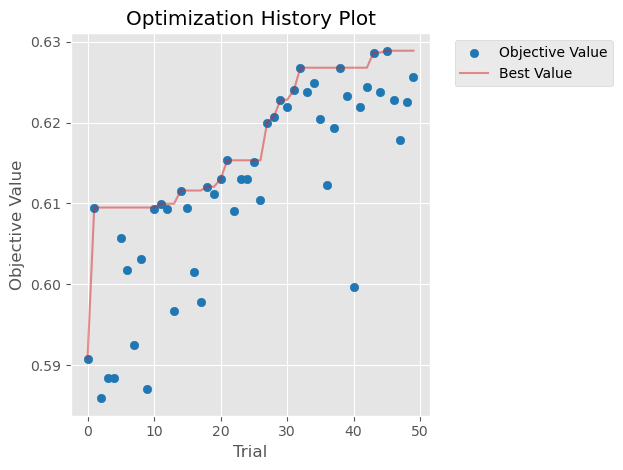

C:\Users\Ewis\AppData\Local\Temp\ipykernel_12524\4059169627.py:13: ExperimentalWarning: optuna.visualization.matplotlib._param_importances.plot_param_importances is experimental (supported from v2.2.0). The interface can change in the future.
  plot_param_importances(study)


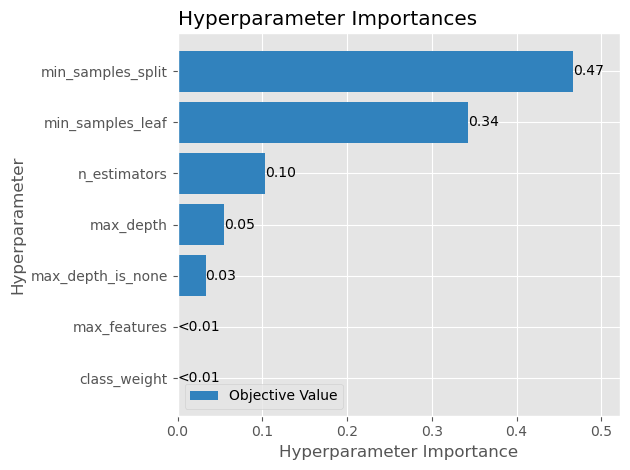

C:\Users\Ewis\AppData\Local\Temp\ipykernel_12524\4059169627.py:18: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  plot_optimization_history(study)
C:\Users\Ewis\AppData\Local\Temp\ipykernel_12524\4059169627.py:23: ExperimentalWarning: optuna.visualization.matplotlib._param_importances.plot_param_importances is experimental (supported from v2.2.0). The interface can change in the future.
  plot_param_importances(study)


In [6]:
import matplotlib.pyplot as plt
from optuna.visualization.matplotlib import (
    plot_optimization_history,
    plot_param_importances
)

plot_optimization_history(study)
plt.tight_layout()
plt.show()

plot_param_importances(study)
plt.tight_layout()
plt.show()

plot_optimization_history(study)
plt.savefig('../../../reports/figures/rf_optimization_history.png',
            dpi=120, bbox_inches='tight')
plt.close()

plot_param_importances(study)
plt.savefig('../../../reports/figures/rf_param_importance.png',
            dpi=120, bbox_inches='tight')
plt.close()

**What we found:**

**Optimization history:** the best value climbed in steps from about 0.591 at trial 1 to 0.6289 at trial 46, with the biggest gains between trials 20 and 33. Improvements after trial 33 were small (0.6268 to 0.6289), so the search was close to plateauing, and more trials would likely add only a fraction of a point. Individual trials are noisy (scores as low as 0.60 even late in the run), which is normal for a search still exploring while it exploits.

**Parameter importance:** `min_samples_split` (0.47) and `min_samples_leaf` (0.34) account for over 80% of the variation in Recall across trials. `n_estimators` adds 0.10, and `max_depth`, `max_depth_is_none`, `max_features`, and `class_weight` all matter little. In plain terms: how aggressively the trees are allowed to split and fragment into small leaves is what moves Recall on this data, not how deep they can grow.

**One caution on reading this chart:** Optuna's importance measures how much a parameter's value varied along with the score across the trials it tried. `max_features` shows under 0.01 partly because the search settled on `None` early and rarely explored the alternatives afterward, so a low score there does not prove the setting is irrelevant.

**Runtime note for the report:** 50 trials took about 60 minutes, with individual trials ranging from 4 seconds to over 4 minutes depending on the settings chosen (large forests with all features at every split were the slow ones).


## 4. Retrain with best parameters and save

In [10]:
best_params = dict(study.best_params)
if best_params.pop('max_depth_is_none'):
    best_params['max_depth'] = None  

best_rf = RandomForestClassifier(**best_params, random_state=42, n_jobs=-1)
best_rf.fit(X_train, y_train)

joblib.dump(best_rf, '../../../models/random_forest_tuned.pkl')

import json
with open('../../../data/processed/optuna_rf_best_params.json', 'w') as f:
    json.dump(best_params, f, indent=2)

print("Saved tuned Random Forest and best parameters.")
print(f"Parameters used: {best_params}")


Saved tuned Random Forest and best parameters.
Parameters used: {'max_depth': 50, 'n_estimators': 124, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': None, 'class_weight': None}


In [11]:
from sklearn.metrics import recall_score, precision_score, f1_score, roc_auc_score, average_precision_score

score = best_rf.predict_proba(X_val)[:, 1]
pred = best_rf.predict(X_val)
tuned = {'Recall': recall_score(y_val, pred), 'Precision': precision_score(y_val, pred),
         'F1': f1_score(y_val, pred), 'ROC-AUC': roc_auc_score(y_val, score),
         'PR-AUC': average_precision_score(y_val, score)}
untuned = {'Recall': 0.6172, 'Precision': 0.7924, 'F1': 0.6939, 'ROC-AUC': 0.7580, 'PR-AUC': 0.8234}
pd.DataFrame({'Untuned RF': untuned, 'Tuned RF': tuned}).round(4)

,Untuned RF,Tuned RF
Recall,0.6172,0.6289
Precision,0.7924,0.7751
F1,0.6939,0.6944
ROC-AUC,0.7580,0.7621
PR-AUC,0.8234,0.8266
